In [1]:
import pandas as pd
import matplotlib.pyplot as plt

series = pd.read_parquet(
    "../data/processed/monthly_series_31.parquet"
)["y"]

series.head()

2022-02-01    2064
2022-03-01    1902
2022-04-01    2097
2022-05-01    2016
2022-06-01    1947
Name: y, dtype: int64

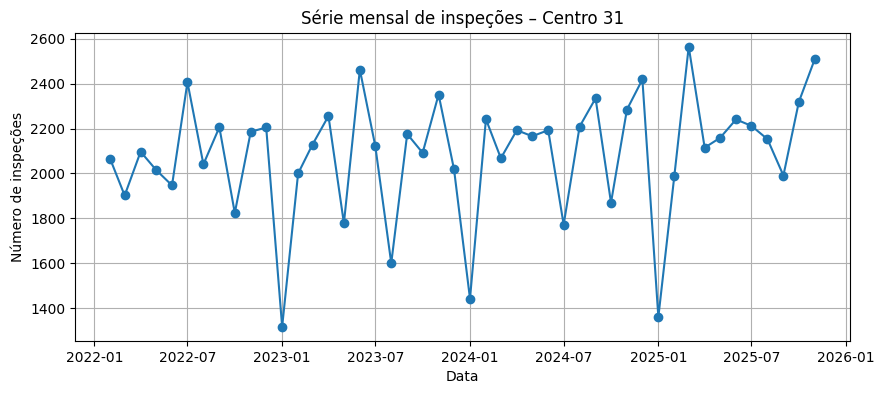

In [2]:
plt.figure(figsize=(10, 4))
plt.plot(series, marker="o")
plt.title("Série mensal de inspeções – Centro 31")
plt.xlabel("Data")
plt.ylabel("Número de inspeções")
plt.grid(True)
plt.show()

In [3]:
series.describe()

count      46.000000
mean     2087.065217
std       273.241643
min      1317.000000
25%      1993.250000
50%      2141.000000
75%      2233.750000
max      2565.000000
Name: y, dtype: float64

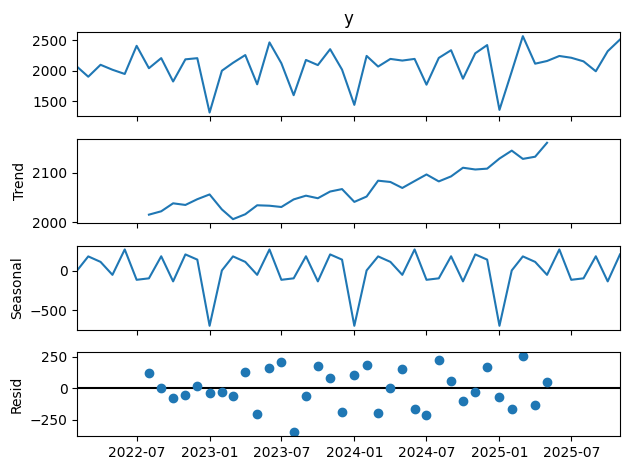

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    series,
    model="additive",
    period=12
)

decomposition.plot()
plt.show()


In [5]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


ADF Statistic: -6.982755710339409
p-value: 8.112486798015139e-10


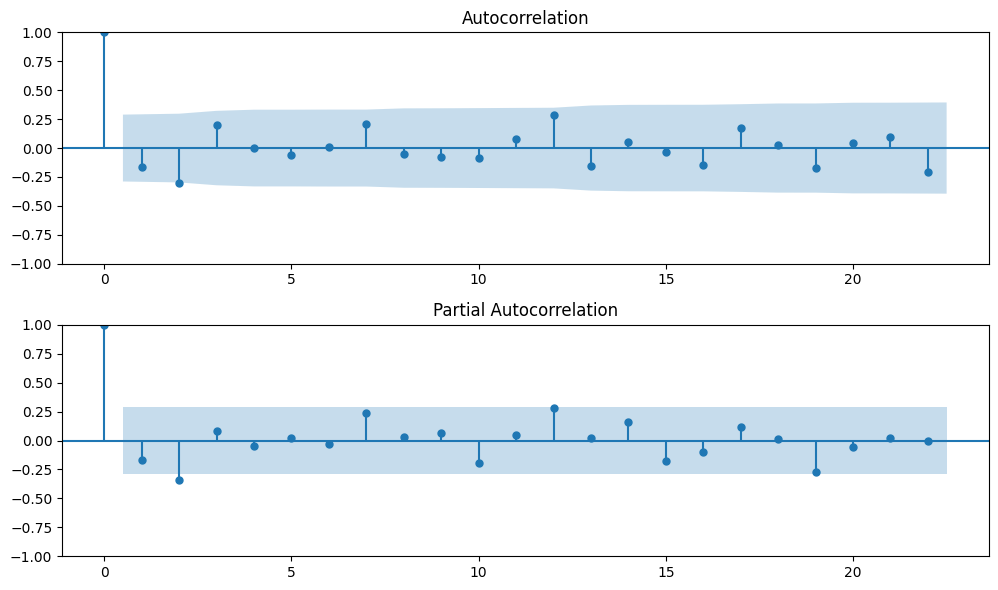

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(series, lags=22, ax=ax[0])
plot_pacf(series, lags=22, ax=ax[1])

plt.tight_layout()
plt.show()


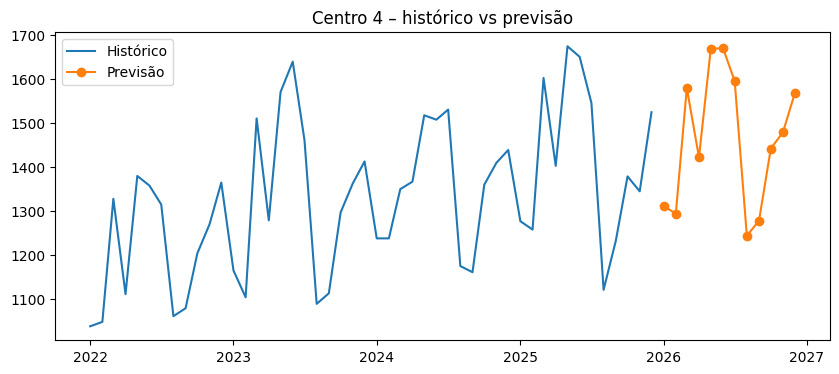

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

hist = pd.read_parquet("../data/processed/monthly_all_centers.parquet")
fcst = pd.read_parquet("../data/processed/forecast_monthly_all_centers.parquet")

center = 4

hist_c = hist[hist["CFGCENTROID"] == center]
fcst_c = fcst[fcst["CFGCENTROID"] == center]

plt.figure(figsize=(10,4))
plt.plot(hist_c["MONTH"], hist_c["y"], label="Histórico")
plt.plot(fcst_c["MONTH"], fcst_c["y_hat"], label="Previsão", marker="o")
plt.legend()
plt.title(f"Centro {center} – histórico vs previsão")
plt.show()


In [4]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# carregar série
df = pd.read_parquet("../data/processed/monthly_all_centers.parquet")
center = 4
series = df[df["CFGCENTROID"] == center].sort_values("MONTH")
y = series["y"].values

# split: último mês como teste
train, test = y[:-1], y[-1:]

# modelo
model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

# previsão 1 mês
y_hat = model.forecast(1)

# erros
mae = mean_absolute_error(test, y_hat)
rmse = np.sqrt(mean_squared_error(test, y_hat))

print(f"Centro {center} – backtest 1 mês")
print(f"Real: {test[0]:.0f}")
print(f"Previsto: {y_hat[0]:.0f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Centro 4 – backtest 1 mês
Real: 1525
Previsto: 1477
MAE: 47.58
RMSE: 47.58
